In [1]:
%pwd
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from experiments.scripts.run_experiments import run_experiment
from experiments.scripts.experiment_utils import generate_experiments

INFO: NumExpr defaulting to 8 threads.


In [3]:
base_config = {
    # Experiment
    "experiment": "e_ae_circle_high",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "s1_high",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "n_points": 10000,
    "embedding_dim": 10,
    "radius": 2,
    "noise_var": 0.0001,
    "deformation_amp": 0.3,

    # Model
    'model_type': 'EuclideanAE',
    "data_dim": 10,
    'latent_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [100,100,100],
    'decoder_widths': [100,100,100],
    'activation': "softplus",

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 100,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,  # Compute topological loss
    'dim_topo_loss': 0,  # Max feature dimension topological loss
    'alpha': 1.0,  # Weight for reconstruction loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "plot_curvatures": True,
    "compute_quadric_curv_inputs": True,
    "compute_quadric_curv_latents": True,
    "compute_quadric_curv_recons": False,
    "compute_true_curv": False,
    "compute_learned_curv": False,
    "n_plot_points": 3000,
    "n_points_emp_curv": 3000,
    "n_points_pullback_curv": 3000, 
    "k": 80,
    "smoothing": False,

    # Persistent homology
    "compute_persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}

param_grid = {
    "alpha": [1] + [1, 1, 0] * 3,
    "gamma": [0] + [1, 100, 1] * 3,
    "dim_topo_loss": [0] + [0] * 3 + [1] * 3 + [2] * 3,
}

all_configs = generate_experiments(base_config, param_grid)


Running exp00_e_ae_circle_high. 
Description: alpha=1, gamma=0, dim_topo_loss=0
--------------------------------------------------------------------------------------


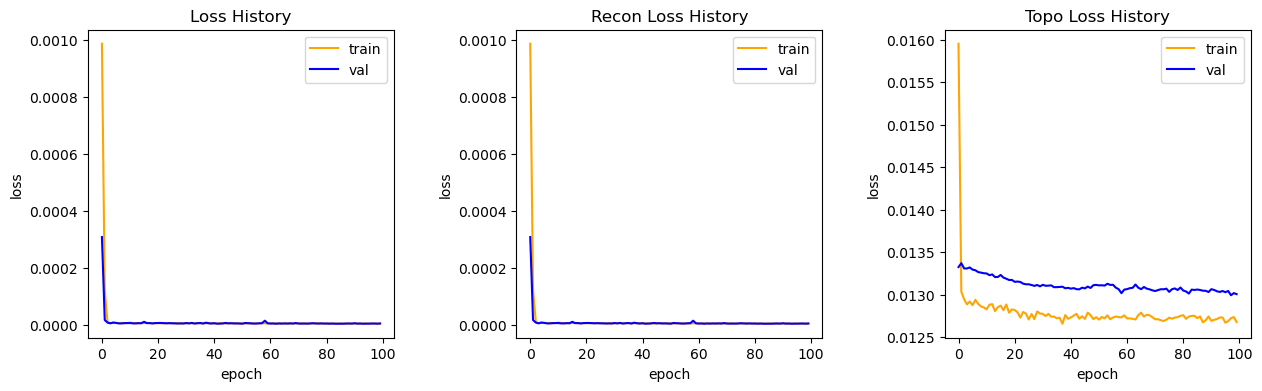

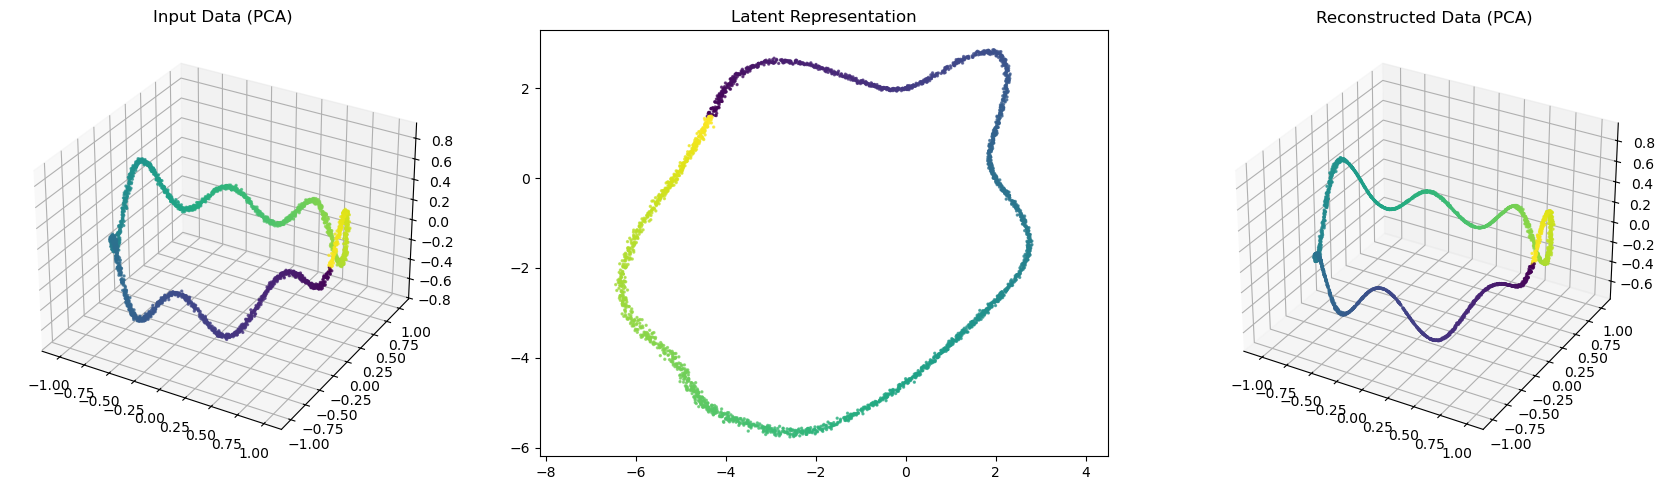

Estimating 1D curvature: 100%|██████████| 3000/3000 [00:02<00:00, 1328.81it/s]


{'quadric_inputs_vs_latents': {'mse': 2.7873067170942663, 'smape': 69.4536541508061}}


<Figure size 640x480 with 0 Axes>

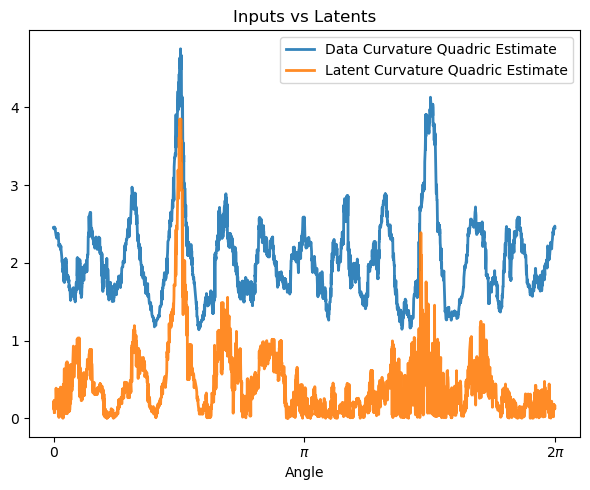

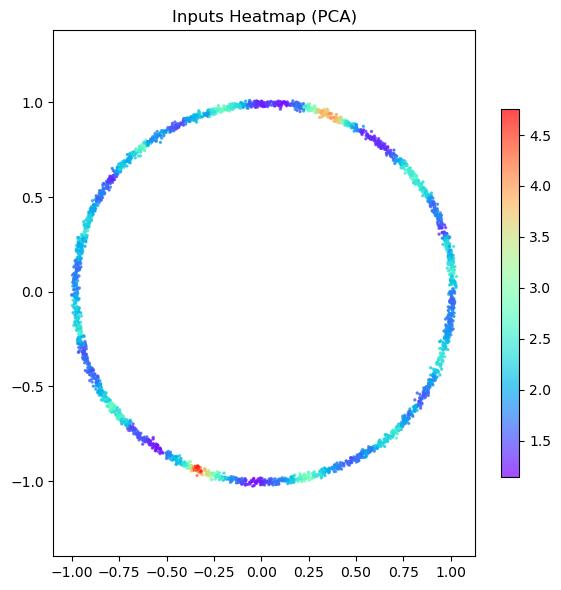

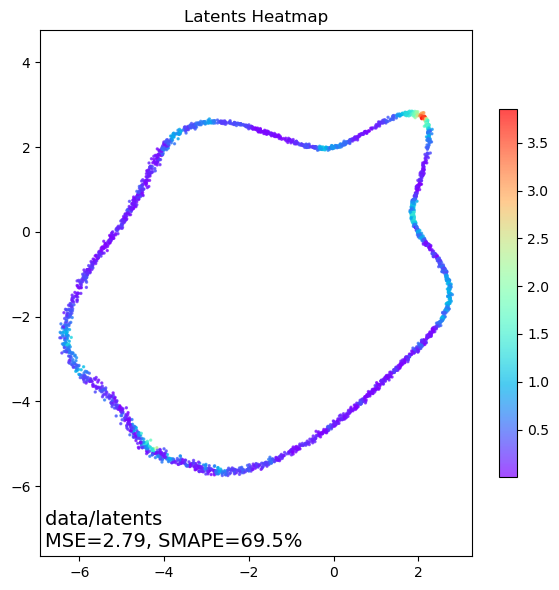

Execution time exp00_e_ae_circle_high: 100.6231 seconds

Running exp01_e_ae_circle_high. 
Description: alpha=1, gamma=1, dim_topo_loss=0
--------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [4]:
run_experiment(all_configs=all_configs)